Accuracy: 0.813953488372093

Confusion Matrix:
[[ 7  5]
 [ 3 28]]

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.70      0.58      0.64        12
      Placed       0.85      0.90      0.88        31

    accuracy                           0.81        43
   macro avg       0.77      0.74      0.76        43
weighted avg       0.81      0.81      0.81        43


Predicted Status: Placed


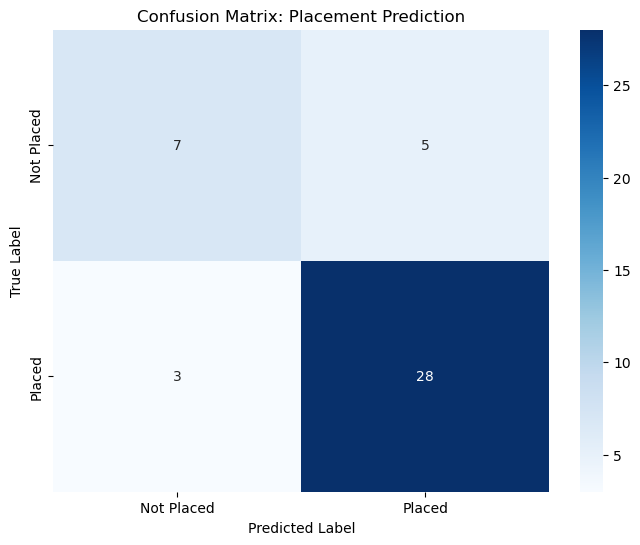

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
data = pd.read_csv("Placement_Data.csv")

# Separate Features and Target
X = data.drop(["status", "salary", "sl_no"], axis=1)
y = data["status"]

#  One-Hot Encoding for Categorical Columns
X = pd.get_dummies(X, drop_first=True)

#  Save Feature Names
feature_names = X.columns

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Feature Scaling (keep as DataFrame)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

#  Create SGD Classifier
model = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)

# Train Model
model.fit(X_train_scaled, y_train)

# Predict on Test Data
y_pred = model.predict(X_test_scaled)

#  Accuracy & Reports
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================
#  Correct New Student Prediction
# ============================

# Create empty student with all features = 0
new_student_dict = dict.fromkeys(feature_names, 0)

# Fill ONLY numerical features (example values)
new_student_dict['ssc_p'] = 67
new_student_dict['hsc_p'] = 91
new_student_dict['degree_p'] = 58
new_student_dict['etest_p'] = 88
new_student_dict['mba_p'] = 67

# Convert to DataFrame with same columns
new_student_df = pd.DataFrame([new_student_dict])

# Scale using same scaler
new_student_scaled = pd.DataFrame(
    scaler.transform(new_student_df),
    columns=feature_names
)

# Predict
pred = model.predict(new_student_scaled)
print("\nPredicted Status:", pred[0])

cm = confusion_matrix(y_test, y_pred)

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)

plt.title('Confusion Matrix: Placement Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()